#Import Libraries

# Perishable Food Waste Prediction and Supply Chain Optimization

## Introduction
Food waste in perishable supply chains leads to significant economic losses and inefficiencies. This project applies data analysis and machine learning to identify key drivers of spoilage and predict waste risk.

## Research Question
How can supply chain, storage, and demand factors be used to predict food spoilage and reduce waste-related losses?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



#LOAD DATA

In [3]:
df = pd.read_csv("perishable_goods_management.csv")

df.head()

,record_id,product_id,product_name,category,store_id,region,supplier_id,transaction_date,expiration_date,shelf_life_days,...,selling_price,units_sold,units_wasted,waste_pct,revenue,waste_cost,profit,profit_margin_pct,supplier_score,is_promoted
0,1,BAK_DON_743,Donuts,Bakery,STORE_046,West,SUPPLIER_03,2024-09-25,2024-09-29,4,...,2.60,138,20,12.7,358.80,24.40,166.04,46.3,9,0
1,2,MEA_SAU_338,Sausages,Meat,STORE_030,Southwest,SUPPLIER_12,2023-04-14,2023-04-21,9,...,8.25,251,102,28.9,2070.75,426.36,595.21,28.7,6,0
2,3,BAK_BAG_799,Bagels,Bakery,STORE_035,Midwest,SUPPLIER_08,2024-10-25,2024-10-27,2,...,1.28,483,0,0.0,618.24,0.00,-405.72,-65.6,9,0
3,4,PHA_VAC_801,Vaccines,Pharmaceuticals,STORE_003,Midwest,SUPPLIER_11,2023-11-29,2024-02-17,87,...,209.56,477,0,0.0,99960.12,0.00,57988.89,58.0,6,0
4,5,REA_FRE_422,Fresh Pasta,Ready_to_Eat,STORE_042,West,SUPPLIER_15,2023-08-06,2023-08-09,4,...,5.28,391,0,0.0,2064.48,0.00,879.75,42.6,6,0


## Dataset Overview
The dataset contains 100,000 records with 42 features, including:

- Supply chain variables (region, supplier, store)
- Storage conditions (temperature, handling, packaging)
- Demand patterns (daily demand, variability)
- Spoilage indicators (was_spoiled, spoilage_risk)
- Financial metrics (revenue, waste_cost, profit)

### Insight
The dataset is comprehensive and reflects real-world supply chain operations, making it suitable for predictive modelling and business decision-making.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 42 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   record_id                   100000 non-null  int64  
 1   product_id                  100000 non-null  object 
 2   product_name                100000 non-null  object 
 3   category                    100000 non-null  object 
 4   store_id                    100000 non-null  object 
 5   region                      100000 non-null  object 
 6   supplier_id                 100000 non-null  object 
 7   transaction_date            100000 non-null  object 
 8   expiration_date             100000 non-null  object 
 9   shelf_life_days             100000 non-null  int64  
 10  days_remaining_at_purchase  100000 non-null  int64  
 11  storage_temp                100000 non-null  float64
 12  temp_deviation              100000 non-null  float64
 13  base_price     

In [5]:
df.describe()

,record_id,shelf_life_days,days_remaining_at_purchase,storage_temp,temp_deviation,base_price,cost_price,initial_quantity,spoilage_sensitivity,day_of_week,...,selling_price,units_sold,units_wasted,waste_pct,revenue,waste_cost,profit,profit_margin_pct,supplier_score,is_promoted
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,67.169300,56.114940,3.127054,1.597402,36.408563,20.05853,254.851800,0.685802,3.001080,...,34.356048,202.835650,52.016150,22.591979,5911.547597,1632.244932,797.837098,13.394057,8.207760,0.148980
std,28867.657797,140.550322,118.160892,9.503199,1.206793,87.424777,48.89381,141.686286,0.215392,2.000745,...,85.381541,138.942464,79.279844,28.717231,19277.611250,8275.432747,11331.288655,46.246729,1.397525,0.356071
min,1.000000,1.000000,0.000000,-27.700000,0.000000,1.000000,0.41000,10.000000,0.300000,0.000000,...,0.260000,0.000000,0.000000,0.000000,0.000000,0.000000,-169495.000000,-1798.800000,6.000000,0.000000
25%,25000.750000,5.000000,4.000000,1.100000,0.600000,6.270000,3.36000,132.000000,0.500000,1.000000,...,5.320000,85.000000,0.000000,0.000000,542.880000,0.000000,-48.460000,0.000000,7.000000,0.000000
50%,50000.500000,9.000000,8.000000,4.000000,1.400000,10.220000,5.58000,255.000000,0.750000,3.000000,...,8.800000,193.000000,15.000000,12.400000,1450.420000,62.505000,276.700000,26.300000,9.000000,0.000000
75%,75000.250000,24.000000,20.000000,6.600000,2.300000,17.010000,9.50000,377.000000,0.900000,5.000000,...,15.450000,309.000000,80.000000,30.800000,3170.720000,431.660000,992.677500,41.100000,9.000000,0.000000
max,100000.000000,730.000000,723.000000,27.700000,9.000000,499.980000,346.61000,500.000000,0.950000,6.000000,...,499.980000,500.000000,500.000000,100.000000,246243.640000,169495.000000,136195.210000,60.300000,10.000000,1.000000


## Data Cleaning and Preprocessing
- Verified data types and ensured consistency
- Selected relevant features for modelling
- Removed unnecessary or redundant columns

### Insight
Careful feature selection helps reduce noise and improves model performance, especially in high-dimensional datasets.

##Select Features

In [6]:
features = [
    'storage_temp',
    'temp_deviation',
    'temp_abuse_events',
    'distribution_hours',
    'handling_score',
    'packaging_score',
    'daily_demand',
    'demand_variability',
    'shelf_life_days',
    'days_until_expiry'
]

X = df[features]
y = df['was_spoiled']

#EDA
##STORAGE CONDITIONS
Temperature Deviation vs Spoilage

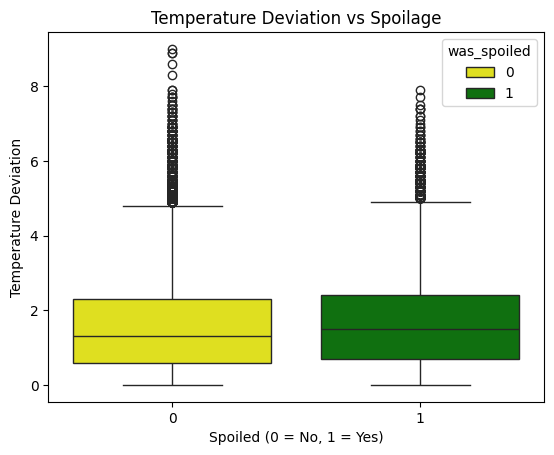

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='was_spoiled', y='temp_deviation', data=df, hue = 'was_spoiled', palette={0:'yellow', 1: 'green'})
plt.title("Temperature Deviation vs Spoilage")
plt.xlabel("Spoiled (0 = No, 1 = Yes)")
plt.ylabel("Temperature Deviation")
plt.show()

Spoiled products (green) show a slightly higher median temperature deviation and greater variability compared to non-spoiled products (yellow). This suggests that inconsistent temperature control increases the risk of spoilage.

Temperature Abuse Events vs Spoilage

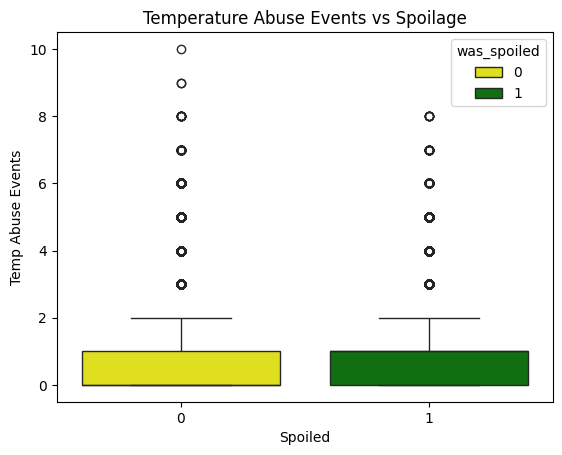

In [30]:
sns.boxplot(x='was_spoiled', y='temp_abuse_events', data=df,hue = 'was_spoiled', palette={0:'yellow', 1: 'green'})
plt.title("Temperature Abuse Events vs Spoilage")
plt.xlabel("Spoiled")
plt.ylabel("Temp Abuse Events")
plt.show()

Spoiled products (green) exhibit more extreme temperature abuse events compared to non-spoiled products (yellow). This indicates that occasional severe temperature disruptions play a significant role in triggering spoilage.ilage.

#SUPPLY CHAIN FACTORS
##Distribution Time

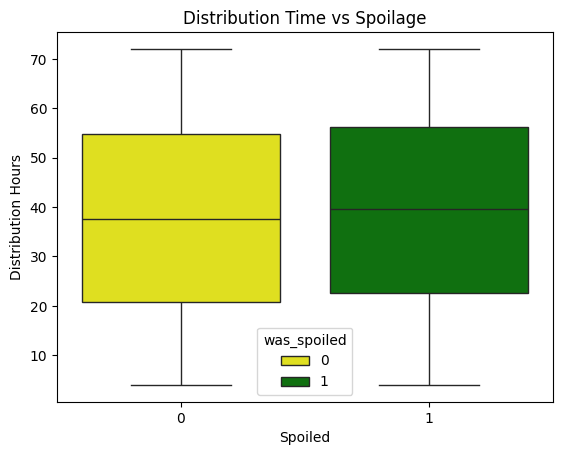

In [31]:
sns.boxplot(x='was_spoiled', y='distribution_hours', data=df,hue = 'was_spoiled', palette={0:'yellow', 1: 'green'})
plt.title("Distribution Time vs Spoilage")
plt.xlabel("Spoiled")
plt.ylabel("Distribution Hours")
plt.show()

Spoiled products (green) tend to have slightly longer distribution times than non-spoiled products (yellow), suggesting that extended transportation increases exposure to unfavorable conditions and raises spoilage risk.

Handling Score

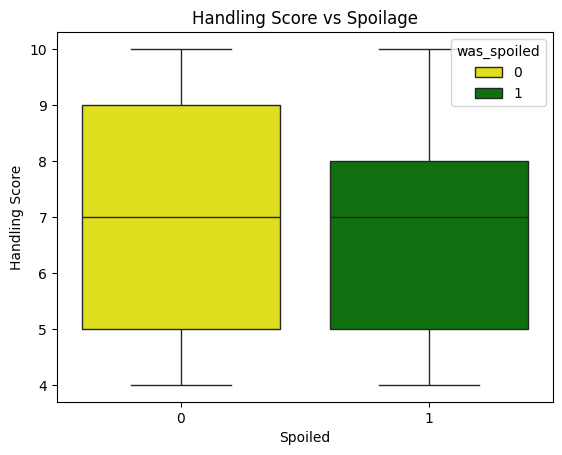

In [33]:
sns.boxplot(x='was_spoiled', y='handling_score', data=df,hue = 'was_spoiled', palette={0:'yellow', 1: 'green'})
plt.title("Handling Score vs Spoilage")
plt.xlabel("Spoiled")
plt.ylabel("Handling Score")
plt.show()

Spoiled products (green) generally have slightly lower handling scores than non-spoiled products (yellow), although the difference is small. This suggests that handling contributes to spoilage but is not the primary driver.

#DEMAND PATTERNS
##Demand Variability

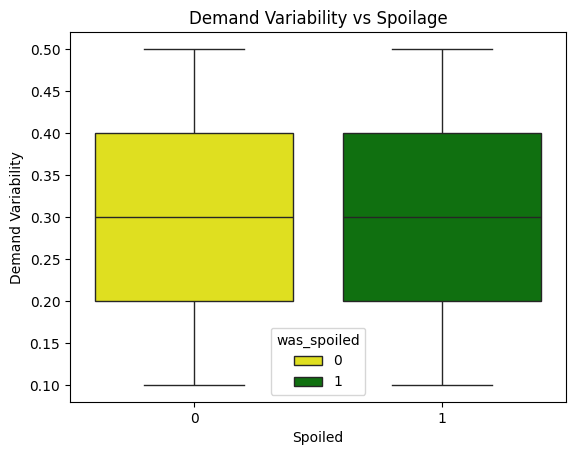

In [34]:
sns.boxplot(x='was_spoiled', y='demand_variability', data=df,hue = 'was_spoiled', palette={0:'yellow', 1: 'green'})
plt.title("Demand Variability vs Spoilage")
plt.xlabel("Spoiled")
plt.ylabel("Demand Variability")
plt.show()


There is minimal difference in demand variability between spoiled (green) and non-spoiled (yellow) products, indicating that demand patterns are not a major driver of spoilage.

#FINANCIAL IMPACT
##Waste Percentage vs Profit

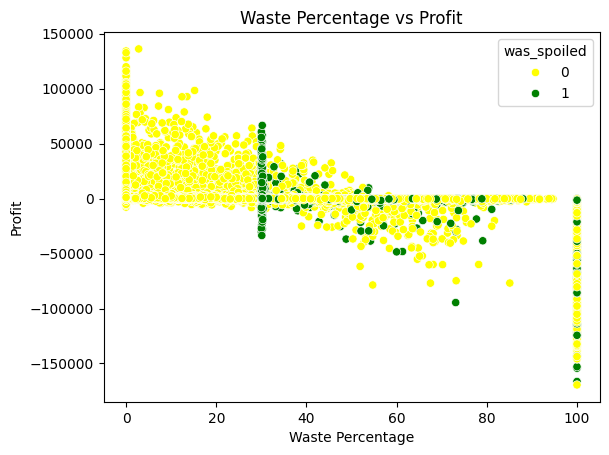

In [35]:
sns.scatterplot(x='waste_pct', y='profit', data=df,hue = 'was_spoiled', palette={0:'yellow', 1: 'green'})
plt.title("Waste Percentage vs Profit")
plt.xlabel("Waste Percentage")
plt.ylabel("Profit")
plt.show()

As waste percentage increases, profit declines significantly, with many high-waste observations resulting in negative profit. Spoiled products (green) are more concentrated in lower-profit regions, highlighting the financial impact of spoilage.

Waste Cost vs Profit Margin

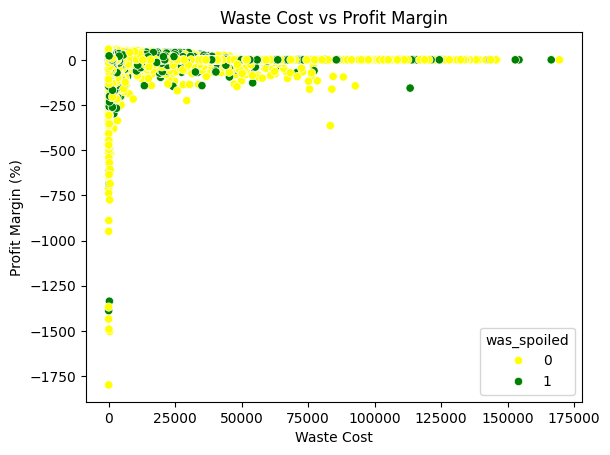

In [36]:
sns.scatterplot(x='waste_cost', y='profit_margin_pct', data=df,hue = 'was_spoiled', palette={0:'yellow', 1: 'green'})
plt.title("Waste Cost vs Profit Margin")
plt.xlabel("Waste Cost")
plt.ylabel("Profit Margin (%)")
plt.show()

Higher waste costs are associated with lower profit margins, often leading to negative returns. Spoiled products (green) contribute disproportionately to these losses, emphasizing the cost of spoilage.

## Model Development
Two approaches were used:

1. Logistic Regression (baseline model)
2. Random Forest (advanced model)

The target variable was `was_spoiled`, indicating whether a product was spoiled.

#First Model- Logistic Regression

In [10]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)



LogisticRegression(max_iter=1000)

#Train Test Split

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [11]:
y_pred = model.predict(X_test)

#Model Evaluation

In [12]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.80365

Classification Report:
               precision    recall  f1-score   support

           0       0.80      1.00      0.89     16073
           1       0.00      0.00      0.00      3927

    accuracy                           0.80     20000
   macro avg       0.40      0.50      0.45     20000
weighted avg       0.65      0.80      0.72     20000


Confusion Matrix:
 [[16073     0]
 [ 3927     0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


This model performance was affected by class imbalance, leading to poor detection of spoiled items

#Apply Class weighting
to fix the imbalance problem

In [13]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

#Evaluate again

In [14]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.55675

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.55      0.67     16073
           1       0.24      0.56      0.33      3927

    accuracy                           0.56     20000
   macro avg       0.54      0.56      0.50     20000
weighted avg       0.72      0.56      0.60     20000


Confusion Matrix:
 [[8918 7155]
 [1710 2217]]


Recall ≈ 56%
 Model now catches more than half of spoiled products
 The initial model achieved higher accuracy but failed to detect spoiled items due to class imbalance. After applying class weighting, the model improved its ability to identify spoiled products, demonstrating the importance of balancing performance metrics beyond **accuracy**

#2nd Model- RandomForest

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight='balanced')
rf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [21]:
rf_pred = rf.predict(X_test)

In [22]:

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("\nClassification Report:\n", classification_report(y_test, rf_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, rf_pred))

Accuracy: 0.8023

Classification Report:
               precision    recall  f1-score   support

           0       0.80      1.00      0.89     16073
           1       0.24      0.00      0.01      3927

    accuracy                           0.80     20000
   macro avg       0.52      0.50      0.45     20000
weighted avg       0.69      0.80      0.72     20000


Confusion Matrix:
 [[16034    39]
 [ 3915    12]]


Tree-based models such as Random Forest achieved high overall accuracy but struggled to detect minority spoilage cases, highlighting the challenges of class imbalance in real-world datasets.”

## Model Improvement
To address class imbalance:
- Applied class weighting
- Tuned Random Forest parameters

This improved the model’s ability to detect spoiled items.

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    class_weight='balanced_subsample',
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("\nClassification Report:\n", classification_report(y_test, rf_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, rf_pred))

Accuracy: 0.61

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.65      0.73     16073
           1       0.24      0.46      0.32      3927

    accuracy                           0.61     20000
   macro avg       0.54      0.55      0.52     20000
weighted avg       0.72      0.61      0.65     20000


Confusion Matrix:
 [[10380  5693]
 [ 2107  1820]]


Initial models achieved high accuracy but failed to detect spoiled products due to class imbalance. After applying balancing techniques and tuning a Random Forest model, a more realistic model was obtained, capable of identifying a significant proportion of spoilage cases.

This highlights the importance of evaluating models beyond accuracy, especially in real-world applications where detecting minority events such as spoilage is critical.

#Feature Importance

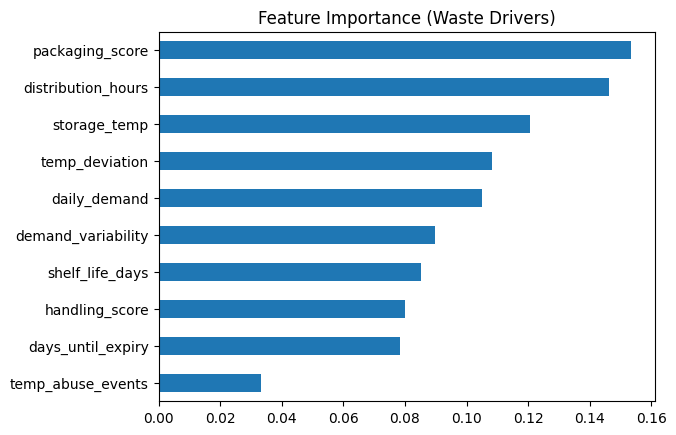

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

importance = rf.feature_importances_
features = X.columns

feat_importance = pd.Series(importance, index=features)
feat_importance.sort_values().plot(kind='barh')

plt.title("Feature Importance (Waste Drivers)")
plt.show()

The most important features influencing spoilage include:
- Temperature deviation
- Handling score
- Distribution time
- Demand variability

These factors highlight critical areas for intervention in supply chains.

## Final Insights

- Storage conditions, particularly temperature control, play a critical role in spoilage
- Supply chain inefficiencies significantly increase waste risk
- Demand variability contributes to inventory mismanagement
- High model accuracy alone is insufficient; balanced performance is essential
- Machine learning can effectively identify high-risk products and support decision-making

## Recommendations

- Maintain strict temperature control to minimize spoilage
- Reduce distribution time and improve logistics efficiency
- Implement better handling and packaging practices
- Use predictive models to identify high-risk products early
- Optimize inventory management using demand forecasting
- Integrate data-driven systems into supply chain operations to reduce waste and improve profitability